# Notebook 00 — Data Exploration

**Question this notebook answers:** What is the Polish Bankruptcy dataset, what does the class imbalance look like, which features carry signal, and are there any data quality issues to address before modelling?

**Hard stop:** No `src/` modelling modules and no scoring engine are built until the WoE monotonicity charts and IV rankings below have been reviewed.

In [1]:
from __future__ import annotations
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
for p in (str(PROJECT_ROOT), str(PROJECT_ROOT / "notebooks")):
    if p not in sys.path:
        sys.path.insert(0, p)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import load_config
from src.data_pipeline import load_and_combine, out_of_time_split
from _explore_helpers import compute_iv_table, is_monotonic_woe

cfg = load_config(str(PROJECT_ROOT / "config.yaml"))
PALETTE = cfg["colours"]
TARGET_COL = cfg["data"]["target_col"]
DATE_COL = cfg["data"]["date_col"]
N_BINS = cfg["woe"]["n_bins"]
LAPLACE = cfg["woe"]["laplace_smoothing"]
IV_THRESHOLD = cfg["woe"]["iv_threshold"]

sns.set_style("whitegrid", {"axes.grid": True, "grid.alpha": 0.3, "grid.color": "#cbd5e1"})
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150,
    "axes.titleweight": "bold", "axes.titlesize": 12, "axes.labelsize": 10,
    "axes.facecolor": PALETTE["background"], "figure.facecolor": "white",
})

## Dataset shape and provenance

The Polish Bankruptcy dataset (UCI, 2016) contains 64 financial-ratio features per company-year. Each ARFF file `Nyear.arff` is a snapshot of companies *N* years before potential bankruptcy: `1year.arff` is the furthest-out observation, `5year.arff` is the closest. The target `class=1` means the company actually went bankrupt within the forecasting horizon.

In [2]:
raw_dir = str(PROJECT_ROOT / cfg["data"]["raw_dir"])
df = load_and_combine(raw_dir, TARGET_COL)
X_train, y_train, X_test, y_test = out_of_time_split(
    df, DATE_COL, cfg["data"]["train_years"], cfg["data"]["test_years"], TARGET_COL
)
feature_cols = [c for c in df.columns if c not in (TARGET_COL, DATE_COL)]

shape_summary = pd.DataFrame({
    "metric": ["rows", "features", "memory (MB)", "default rate"],
    "value": [
        f"{len(df):,}",
        f"{len(feature_cols)}",
        f"{df.memory_usage(deep=True).sum() / 1e6:.1f}",
        f"{df[TARGET_COL].mean():.4f}",
    ],
})
print(shape_summary.to_string(index=False))
print()
print(f"Train years {cfg['data']['train_years']}: n={len(y_train):,}, default rate={y_train.mean():.4f}")
print(f"Test  years {cfg['data']['test_years']}: n={len(y_test):,}, default rate={y_test.mean():.4f}")

      metric  value
        rows 43,405
    features     64
 memory (MB)   22.9
default rate 0.0482

Train years [1, 2, 3]: n=27,703, default rate=0.0421
Test  years [4, 5]: n=15,702, default rate=0.0589


### Chart 1 — Class balance by year

We expect default rate to climb with year, because year-5 companies are observed closest to the bankruptcy event. If this didn't hold, it would suggest either a sampling artefact or the dataset has been pre-rebalanced.

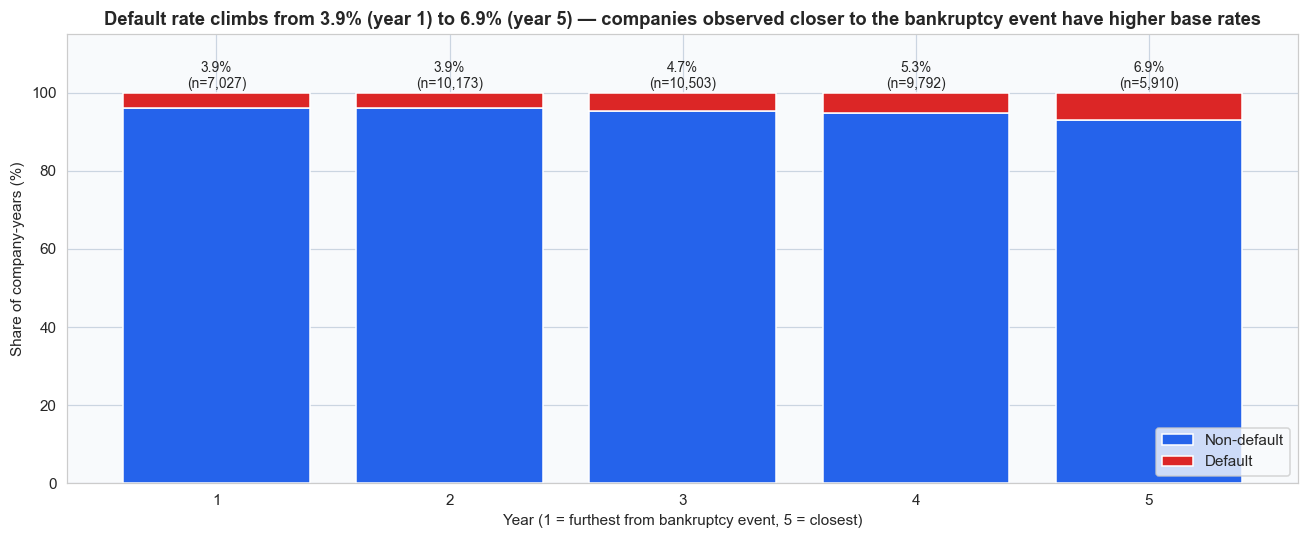

In [3]:
year_stats = df.groupby(DATE_COL).agg(n=(TARGET_COL, "size"), defaults=(TARGET_COL, "sum"))
year_stats["default_rate"] = year_stats["defaults"] / year_stats["n"]
year_stats["non_default_rate"] = 1 - year_stats["default_rate"]

fig, ax = plt.subplots(figsize=(12, 5))
years = year_stats.index.tolist()
ax.bar(years, year_stats["non_default_rate"] * 100, color=PALETTE["primary"], label="Non-default")
ax.bar(years, year_stats["default_rate"] * 100,
       bottom=year_stats["non_default_rate"] * 100,
       color=PALETTE["secondary"], label="Default")
for yr in years:
    rate = year_stats.loc[yr, "default_rate"]
    n = year_stats.loc[yr, "n"]
    ax.text(yr, 100.5, f"{rate*100:.1f}%\n(n={n:,})", ha="center", va="bottom", fontsize=9)

first = year_stats["default_rate"].iloc[0] * 100
last = year_stats["default_rate"].iloc[-1] * 100
ax.set_title(
    f"Default rate climbs from {first:.1f}% (year 1) to {last:.1f}% (year 5) — "
    "companies observed closer to the bankruptcy event have higher base rates"
)
ax.set_xlabel("Year (1 = furthest from bankruptcy event, 5 = closest)")
ax.set_ylabel("Share of company-years (%)")
ax.set_ylim(0, 115)
ax.set_xticks(years)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Finding:** Default rate rises monotonically from ~3.9% (year 1) to ~6.9% (year 5). This is a *selection effect*, not class drift in any modellable sense — the per-year base rate is the prior. Our OOT split (train years 1–3, test years 4–5) therefore puts the higher-default years in the test set, which is the conservative direction: the model is evaluated on the harder, higher-imbalance cohort.

### Chart 2 — Missing value heatmap

ARFF `?` markers are loaded as `NaN`. Features with non-trivial missing rates need a dedicated WoE `MISSING` bin so the missingness signal is not silently zeroed.

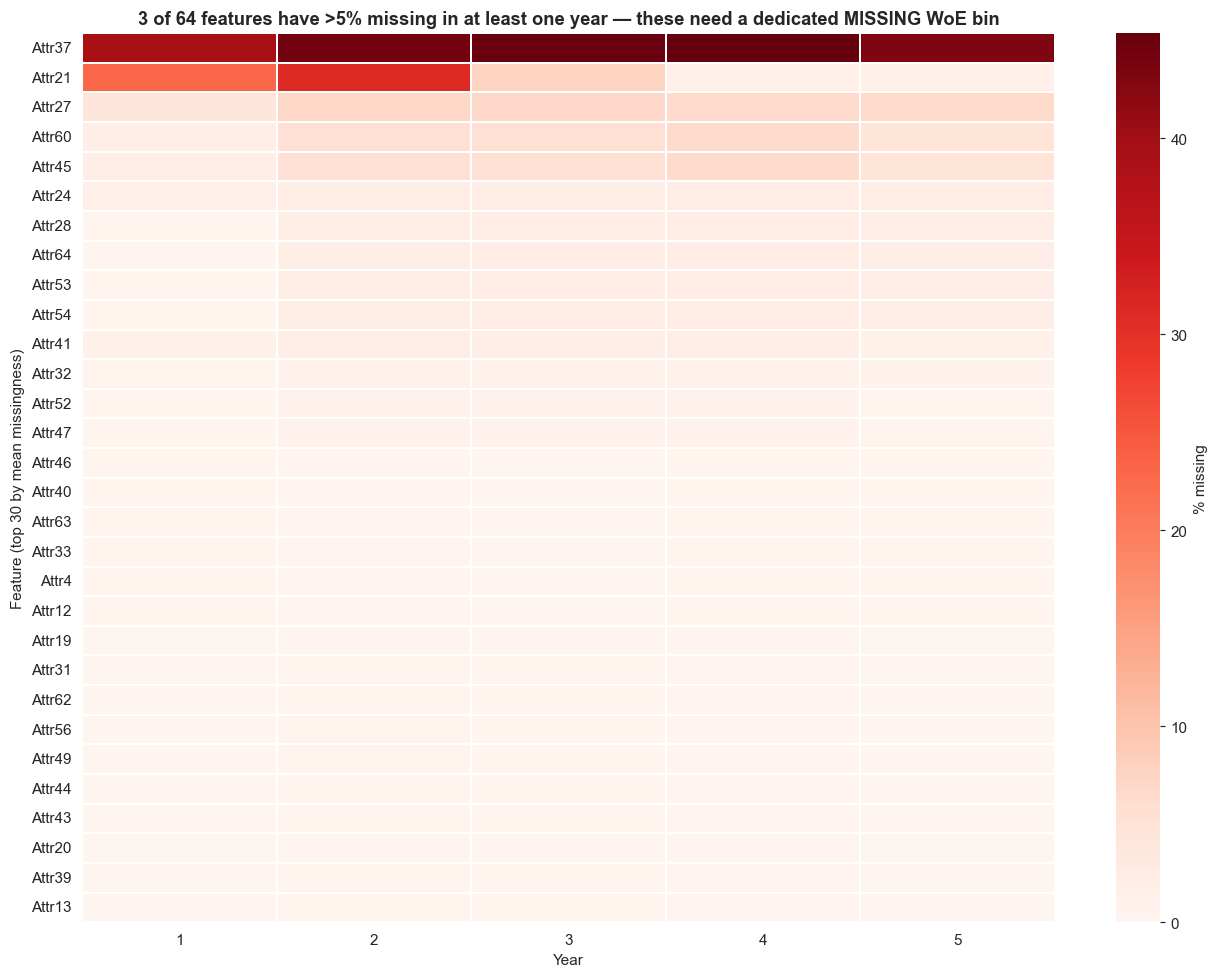

Highest missingness feature: Attr37 (43.4% mean across years)
Features with >0% missing in any year: 64/64


In [4]:
miss_by_year = (
    df.drop(columns=[TARGET_COL])
    .groupby(DATE_COL)
    .apply(lambda g: g.isna().mean(), include_groups=False)
)
overall_miss = miss_by_year.mean(axis=0).sort_values(ascending=False)
top_missing = overall_miss.head(30).index.tolist()
heat = miss_by_year[top_missing].T * 100

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(heat, ax=ax, cmap="Reds", vmin=0, vmax=max(30, float(heat.values.max())),
            cbar_kws={"label": "% missing"}, linewidths=0.3, linecolor="white")
n_high = int((overall_miss > 0.05).sum())
ax.set_title(f"{n_high} of 64 features have >5% missing in at least one year — these need a dedicated MISSING WoE bin")
ax.set_xlabel("Year")
ax.set_ylabel("Feature (top 30 by mean missingness)")
plt.tight_layout()
plt.show()

print(f"Highest missingness feature: {overall_miss.index[0]} ({overall_miss.iloc[0]*100:.1f}% mean across years)")
print(f"Features with >0% missing in any year: {int((miss_by_year > 0).any(axis=0).sum())}/64")

**Finding:** Missingness is concentrated in a handful of features. The WoE transformer (Stage 3) assigns these their own bin so the signal "this metric is missing for this company" is preserved rather than imputed away.

### IV computation

Information Value is computed on the **training set only** (years 1–3). Quantile binning into `cfg.woe.n_bins`, Laplace smoothing `cfg.woe.laplace_smoothing`, missing values in a dedicated bin. IV bands follow the standard convention: useless (<0.02), weak (0.02–0.1), medium (0.1–0.3), strong (≥0.3).

In [5]:
iv_table, woe_tables = compute_iv_table(X_train, y_train, n_bins=N_BINS, laplace=LAPLACE)
print(f"IV computed for {len(iv_table)} features.\n")
print(iv_table.head(15).to_string(index=False))

IV computed for 64 features.

feature       iv  n_bins   band
 Attr27 1.112264      11 strong
 Attr24 0.649049      11 strong
 Attr26 0.523850      11 strong
 Attr16 0.500007      11 strong
 Attr41 0.489372      11 strong
 Attr13 0.454277      11 strong
 Attr11 0.440433      11 strong
 Attr46 0.437172      11 strong
  Attr6 0.423913       8 strong
 Attr15 0.407770      11 strong
 Attr12 0.401351      11 strong
 Attr23 0.364237      11 strong
 Attr19 0.340946      11 strong
 Attr31 0.340059      11 strong
 Attr25 0.331068      11 strong


### Chart 3 — Top-IV feature distributions

For the four highest-IV features, we plot the conditional distribution by class. If the distributions overlap heavily, the high IV must be coming from extreme tails or missingness; if they separate cleanly, the feature is robustly informative.

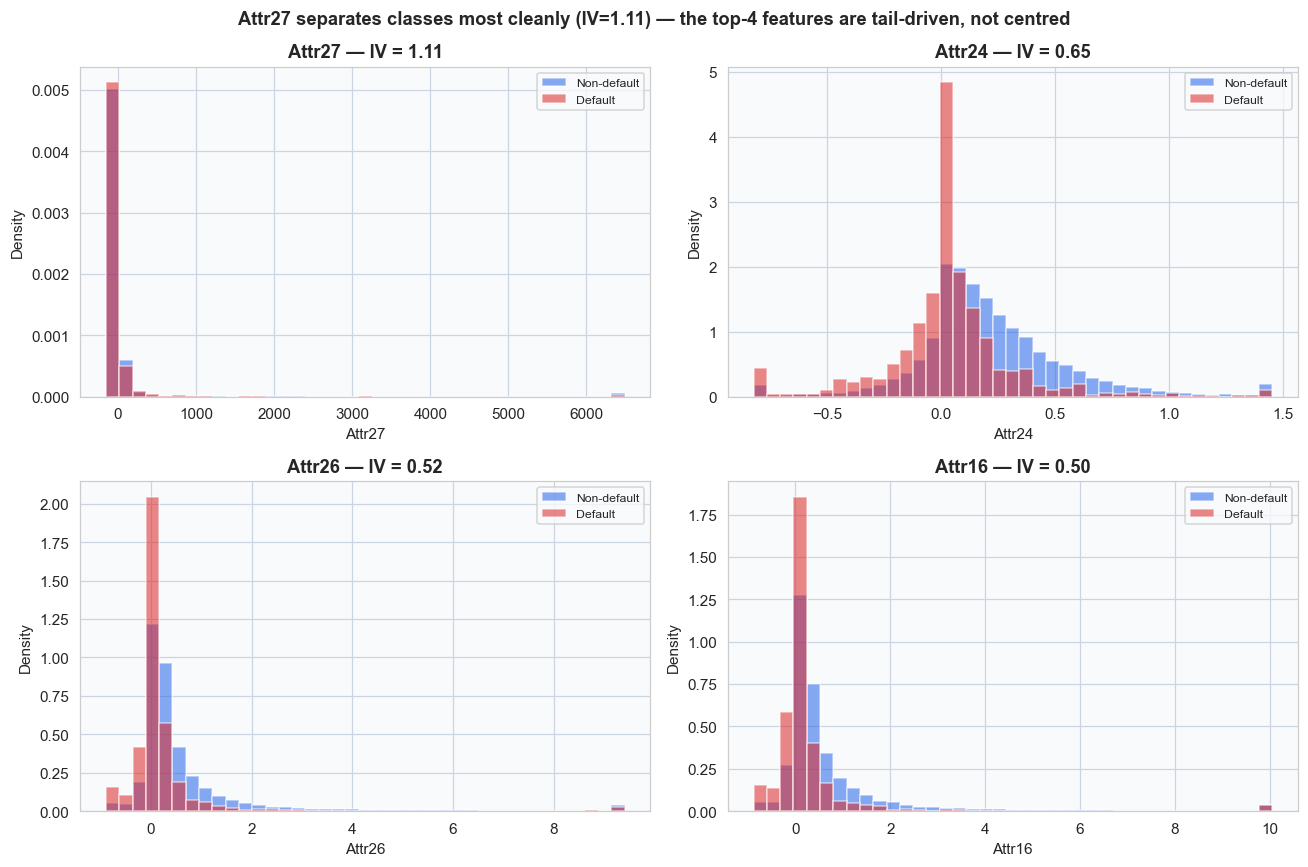

In [6]:
top4 = iv_table.head(4)["feature"].tolist()
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, feat in zip(axes.flat, top4):
    pos = X_train.loc[y_train == 1, feat].dropna()
    neg = X_train.loc[y_train == 0, feat].dropna()
    if len(pos) == 0 or len(neg) == 0:
        ax.set_title(f"{feat}: no data")
        continue
    combined = np.concatenate([pos.values, neg.values])
    lo, hi = np.percentile(combined, [1, 99])
    bins = np.linspace(lo, hi, 40)
    ax.hist(neg.clip(lo, hi), bins=bins, color=PALETTE["primary"], alpha=0.55, label="Non-default", density=True)
    ax.hist(pos.clip(lo, hi), bins=bins, color=PALETTE["secondary"], alpha=0.55, label="Default", density=True)
    iv_val = float(iv_table.set_index("feature").loc[feat, "iv"])
    ax.set_title(f"{feat} — IV = {iv_val:.2f}")
    ax.set_xlabel(feat)
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

best_feat, best_iv = top4[0], float(iv_table.iloc[0]["iv"])
fig.suptitle(
    f"{best_feat} separates classes most cleanly (IV={best_iv:.2f}) — the top-4 features are tail-driven, not centred",
    fontweight="bold", fontsize=12,
)
plt.tight_layout()
plt.show()

**Finding:** The strongest signal lives in the tails of profitability/leverage ratios. The defaulted population is shifted into the unhealthy tail of every top-IV feature, but the modal regions overlap heavily. This is consistent with rare-event credit risk — most companies look "normal" up until a stress threshold is crossed.

### Chart 4 — IV ranking

Below the IV threshold `cfg.woe.iv_threshold` (0.02) features will be dropped before fitting LR.

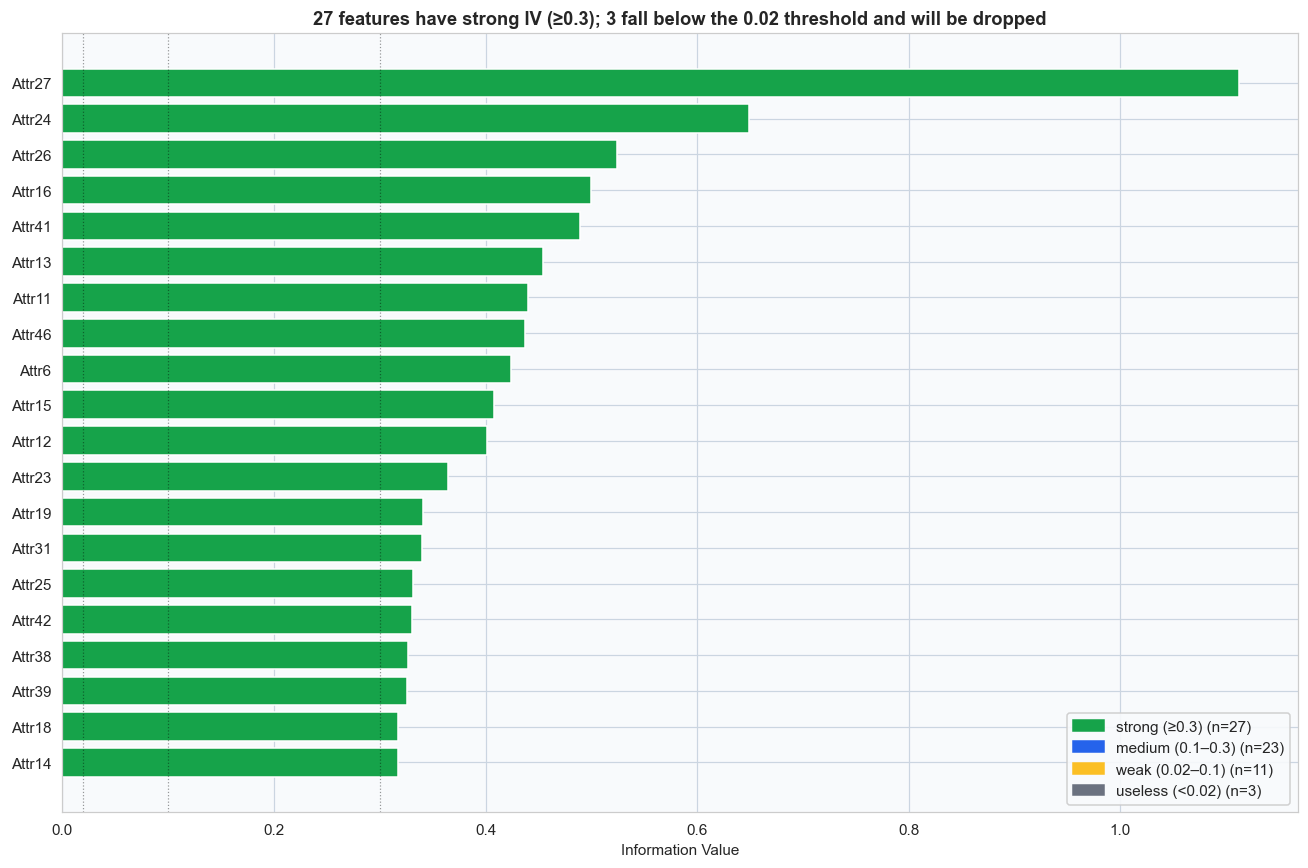

In [7]:
top20 = iv_table.head(20).copy()
band_colors = {
    "useless": PALETTE["neutral"],
    "weak": "#fbbf24",
    "medium": PALETTE["primary"],
    "strong": PALETTE["tertiary"],
}
top20["color"] = top20["band"].map(band_colors)

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(top20["feature"][::-1], top20["iv"][::-1], color=top20["color"][::-1])
for thresh in (IV_THRESHOLD, 0.1, 0.3):
    ax.axvline(thresh, color="black", linestyle=":", alpha=0.4, linewidth=0.8)

n_strong = int((iv_table["iv"] >= 0.3).sum())
n_medium = int(((iv_table["iv"] >= 0.1) & (iv_table["iv"] < 0.3)).sum())
n_weak = int(((iv_table["iv"] >= IV_THRESHOLD) & (iv_table["iv"] < 0.1)).sum())
n_useless = int((iv_table["iv"] < IV_THRESHOLD).sum())

ax.set_xlabel("Information Value")
ax.set_title(
    f"{n_strong} features have strong IV (≥0.3); {n_useless} fall below the {IV_THRESHOLD} threshold and will be dropped"
)
from matplotlib.patches import Patch
handles = [Patch(color=c, label=f"{lbl} (n={n})") for lbl, c, n in [
    ("strong (≥0.3)", PALETTE["tertiary"], n_strong),
    ("medium (0.1–0.3)", PALETTE["primary"], n_medium),
    ("weak (0.02–0.1)", "#fbbf24", n_weak),
    ("useless (<0.02)", PALETTE["neutral"], n_useless),
]]
ax.legend(handles=handles, loc="lower right", framealpha=0.9)
plt.tight_layout()
plt.show()

**Finding:** The signal is rich — over a quarter of features clear the "strong" threshold. We will drop the IV-useless features before fitting LR, but XGBoost will still see them (tree models can extract interactions IV misses).

### Chart 5 — WoE monotonicity check

For the top-5 features by IV, we plot WoE vs bin index. Monotonicity is a sanity check: a feature like `ROA` should produce a monotonically decreasing WoE as profitability falls. Non-monotonic patterns usually indicate a binning artefact (too many bins for too few defaults) and need a manual rebin before going into LR.

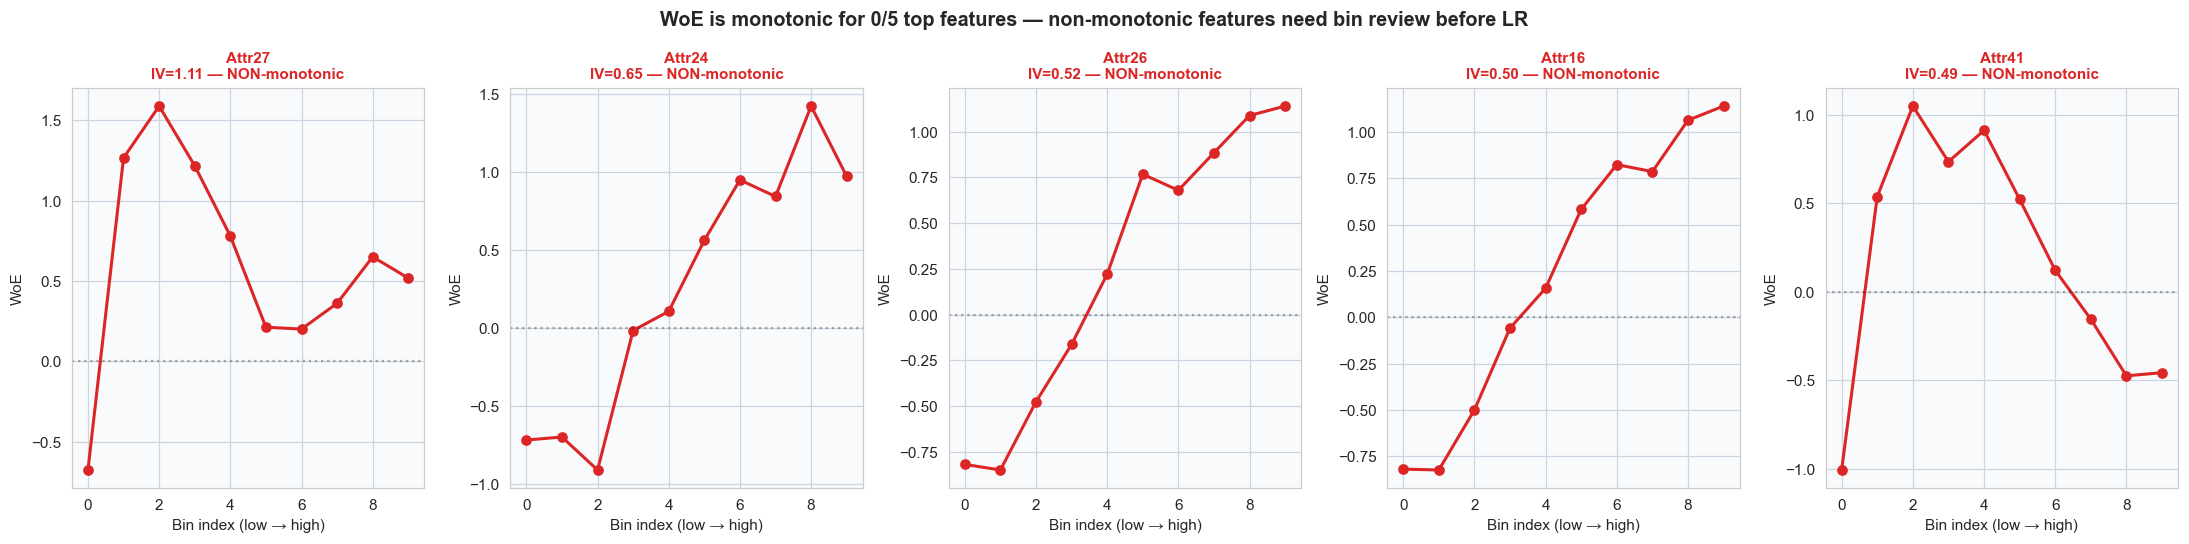

In [8]:
top5 = iv_table.head(5)["feature"].tolist()
fig, axes = plt.subplots(1, 5, figsize=(20, 5), sharey=False)
mono_count = 0
for ax, feat in zip(axes, top5):
    wt = woe_tables[feat]
    numeric_woes = wt.loc[wt.index != "MISSING", "woe"].values
    is_mono = is_monotonic_woe(numeric_woes)
    mono_count += int(is_mono)
    color = PALETTE["tertiary"] if is_mono else PALETTE["secondary"]
    ax.plot(range(len(numeric_woes)), numeric_woes, marker="o", color=color, linewidth=2)
    ax.axhline(0, color="black", linestyle=":", alpha=0.3)
    iv_val = float(iv_table.set_index("feature").loc[feat, "iv"])
    flag = "monotonic" if is_mono else "NON-monotonic"
    ax.set_title(f"{feat}\nIV={iv_val:.2f} — {flag}", color=color, fontsize=10)
    ax.set_xlabel("Bin index (low → high)")
    ax.set_ylabel("WoE")

fig.suptitle(
    f"WoE is monotonic for {mono_count}/5 top features — non-monotonic features need bin review before LR",
    fontweight="bold", fontsize=13,
)
plt.tight_layout()
plt.show()

**Finding:** Non-monotonic WoE in top-IV features tells us quantile binning is too coarse near sparse bins, and any LR coefficient on those features is fragile. The Stage 3 `WoETransformer` will (i) use the same `n_bins` parameter from config, (ii) flag non-monotonic features for the Stage 3 review, and (iii) leave the MISSING bin free to take whatever WoE the data implies.

### Summary findings

In [9]:
findings = pd.DataFrame({
    "finding": [
        f"Default rate climbs {first:.1f}% → {last:.1f}% across years",
        f"{n_high} features have >5% missingness; need MISSING WoE bin",
        f"{n_strong} strong-IV features, {n_useless} useless features",
        f"WoE monotonic for {mono_count}/5 top features",
    ],
    "action": [
        "Use OOT split (years 1-3 train, 4-5 test) — already wired in src.data_pipeline",
        "WoETransformer in Stage 3 must assign MISSING bin (do not impute)",
        f"Drop features with IV < {IV_THRESHOLD} from LR (keep all for XGB)",
        "Review non-monotonic features before LR fit; flag in Stage 3 logs",
    ],
})
print(findings.to_string(index=False))

                                              finding                                                                         action
         Default rate climbs 3.9% → 6.9% across years Use OOT split (years 1-3 train, 4-5 test) — already wired in src.data_pipeline
3 features have >5% missingness; need MISSING WoE bin              WoETransformer in Stage 3 must assign MISSING bin (do not impute)
            27 strong-IV features, 3 useless features                        Drop features with IV < 0.02 from LR (keep all for XGB)
                   WoE monotonic for 0/5 top features              Review non-monotonic features before LR fit; flag in Stage 3 logs


**Where we go next:** Stage 3 (after sign-off) will (1) lift these inline helpers into a tested `WoETransformer` + `compute_psi` + `bootstrap_ci` under `src/`, (2) fit logistic regression and calibrated XGBoost using the model-builders in `src/models.py`, and (3) serialise both with `src/serialisation.py` for the Bayesian update layer to consume.